# SARIMAX Modelling for NSW Electricity Demand Forecasting

## 1. Objective

The aim of this notebook is to develop a SARIMAX model to forecast NSW electricity demand using historical demand and selected exogenous variables. The model will be evaluated over multiple forecasting horizons using mean squared error (MSE) and root mean squared error (RMSE). The results will then be compared with the provided forecast and other forecasting models used in the project.

## 2. Import libraries

This section imports the Python libraries required for data handling, visualisation, time series modelling, and model evaluation.

- `pandas` and `numpy` are used for data manipulation
- `matplotlib` is used for visualisation
- `statsmodels` provides the SARIMAX model
- `sklearn` is used to calculate evaluation metrics such as MSE and RMSE

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

## 3. Load data

In this section, the preprocessed training, validation, and test datasets are loaded. These datasets were generated during the preprocessing stage to ensure consistency across all models in the project.

Using pre-split datasets allows for a fair comparison between models and avoids data leakage. The data is recorded at an hourly frequency, which will inform the seasonal structure of the SARIMAX model.

The model will be trained on the training set and evaluated on the validation and test sets.

In [48]:
# Load datasets from project root (notebook in src/)
from pathlib import Path
root = Path.cwd().resolve().parents[0]  # project root when running from src/

train_path = root / 'data' / 'NSW' / 'train.csv'
validation_path = root / 'data' / 'NSW' / 'validation.csv'
test_path = root / 'data' / 'NSW' / 'test.csv'


train = pd.read_csv(train_path, parse_dates=['DATETIME'], index_col='DATETIME')
validation = pd.read_csv(validation_path, parse_dates=['DATETIME'], index_col='DATETIME')
test = pd.read_csv(test_path, parse_dates=['DATETIME'], index_col='DATETIME')

# Quick check
print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (53697, 6)
Validation shape: (17899, 6)
Test shape: (17900, 6)


,TOTALDEMAND,TEMPERATURE,FORECASTDEMAND,demand_1_day_ago,demand_1_week_ago,demand_1_year_ago
DATETIME,,,,,,
2011-01-01 00:00:00,8063.36,21.0,8667.554234,7628.57,7358.22,8038.00
2011-01-01 01:00:00,7545.29,19.5,8707.696355,7161.66,6870.62,7483.69
2011-01-01 02:00:00,6824.75,18.6,8774.391068,6594.82,6237.94,6812.03
2011-01-01 03:00:00,6435.10,18.4,8870.441919,6317.23,5871.85,6377.32
2011-01-01 04:00:00,6227.71,18.2,8980.444211,6295.38,5751.73,6211.49


## 4. Data inspection

Before fitting the model, the structure and properties of the dataset are examined. 
This includes checking the data types, confirming the presence of key variables, and ensuring that the datetime index is correctly formatted.

Understanding the dataset at this stage helps identify any potential issues and ensures that the SARIMAX model is applied appropriately.

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 53697 entries, 2011-01-01 00:00:00 to 2017-02-15 08:00:00
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TOTALDEMAND        53697 non-null  float64
 1   TEMPERATURE        53697 non-null  float64
 2   FORECASTDEMAND     53697 non-null  float64
 3   demand_1_day_ago   53697 non-null  float64
 4   demand_1_week_ago  53697 non-null  float64
 5   demand_1_year_ago  53697 non-null  float64
dtypes: float64(6)
memory usage: 2.9 MB


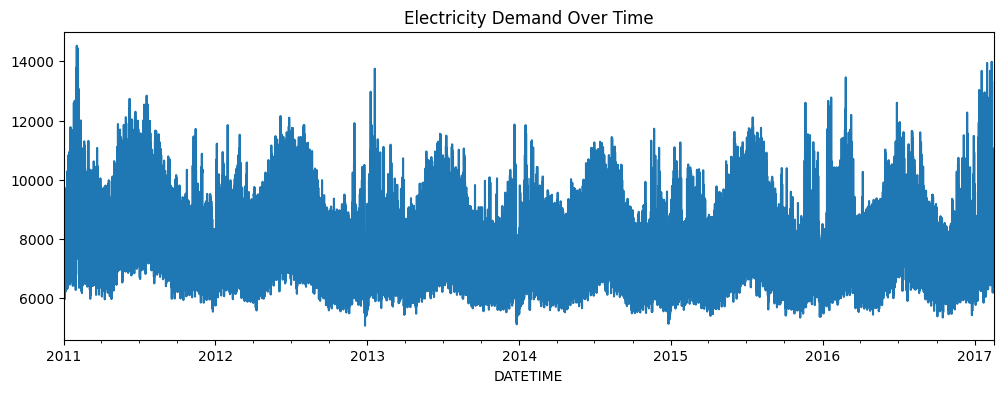

In [49]:
# Check data types and structure
train.info()

# Summary statistics
train.describe()

# Check for missing values
train.isna().sum()

# Quick visual of target variable
train['TOTALDEMAND'].plot(figsize=(12,4), title='Electricity Demand Over Time')
plt.show()

The time series plot shows clear periodic patterns, including strong daily cycles and longer-term seasonal variation. This indicates that electricity demand is influenced by recurring temporal patterns, making it suitable for a seasonal time series model such as SARIMAX.

Additionally, the data is recorded at an hourly frequency, which informs the choice of a seasonal period of 24 when specifying the SARIMAX model.

In [50]:
# Set hourly frequency for time series modelling (required for SARIMAX)
train = train.sort_index()
validation = validation.sort_index()
test = test.sort_index()

train.index.freq = 'h'
validation.index.freq = 'h'
test.index.freq = 'h'
train.index.to_series().diff().value_counts().head()

DATETIME
0 days 01:00:00    53696
Name: count, dtype: int64

## 5. Define target and exogenous variables

The target variable for the model is total electricity demand (`TOTALDEMAND`).

Two exogenous variables are included: temperature and forecast demand. Temperature captures the impact of weather conditions on electricity usage, while the provided forecast demand represents an external benchmark prediction.

Lagged demand variables were considered but not included in the final SARIMAX model. This is because multi-step forecasting requires exogenous variables to be known in advance, and lagged demand values are not available for future time steps without recursive prediction.

Including temperature and forecast demand allows the model to incorporate both external influences and baseline demand expectations while maintaining a valid forecasting setup.

In [51]:
# Target variable
y_train = train['TOTALDEMAND']
y_val = validation['TOTALDEMAND']
y_test = test['TOTALDEMAND']

# Exogenous variables
exog_vars = ['TEMPERATURE', 'FORECASTDEMAND']

X_train = train[exog_vars]
X_val = validation[exog_vars]
X_test = test[exog_vars]
print(X_train.head())

                     TEMPERATURE  FORECASTDEMAND
DATETIME                                        
2011-01-01 00:00:00         21.0     8667.554234
2011-01-01 01:00:00         19.5     8707.696355
2011-01-01 02:00:00         18.6     8774.391068
2011-01-01 03:00:00         18.4     8870.441919
2011-01-01 04:00:00         18.2     8980.444211


## Helper functions

To keep the notebook concise and consistent, helper functions are defined for forecasting, metric calculation, and visualisation. 
This avoids unnecessary repetition and ensures that each model is evaluated using the same process.

In [52]:
def run_forecast(model_results, X_test, y_test, window_start, horizon):
    """
    Generate forecast and calculate error metrics for a given horizon.
    """
    y_actual = y_test.iloc[window_start:window_start + horizon]
    X_exog = X_test.iloc[window_start:window_start + horizon]

    forecast = model_results.get_forecast(
        steps=horizon,
        exog=X_exog
    )

    y_pred = forecast.predicted_mean

    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mse = mean_squared_error(y_actual, y_pred)

    return y_actual, y_pred, rmse, mse


def plot_forecast(y_actual, y_pred, provided_forecast, horizon, title):
    """
    Plot actual demand, model forecast, and provided forecast.
    """
    plt.figure(figsize=(10, 5))

    plt.plot(range(horizon), y_actual.values, label='Actual Demand')
    plt.plot(range(horizon), y_pred.values, label=title)
    plt.plot(range(horizon), provided_forecast.values, label='Provided Forecast')

    plt.title(f'{horizon}-step Forecast Comparison')
    plt.xlabel('Step Ahead')
    plt.ylabel('Electricity Demand')
    plt.legend()
    plt.grid()
    plt.show()

## 6. Baseline Model

### 6.1 Model Specification

The first model developed in this notebook is a baseline SARIMAX model. This model is intended to provide an interpretable statistical benchmark for forecasting NSW electricity demand.

The target variable is `TOTALDEMAND`, while `TEMPERATURE` and `FORECASTDEMAND` are included as exogenous variables. Temperature is included because electricity demand is influenced by weather conditions, while the provided forecast demand acts as an external benchmark that the SARIMAX model can refine.

Given that the data is recorded hourly, a seasonal period of 24 is used to represent daily seasonality. A relatively simple model structure is used to keep the baseline interpretable and computationally efficient.

The baseline model specification is:
- non-seasonal order: (1,1,0)
- seasonal order: (0,1,0,24)

In [53]:
# Clean and align training data
combined_train = pd.concat([y_train, X_train], axis=1).dropna()

y_train_clean = combined_train['TOTALDEMAND']
X_train_clean = combined_train[['TEMPERATURE', 'FORECASTDEMAND']]

# Fit baseline SARIMAX model
model_baseline = SARIMAX(
    y_train_clean,
    exog=X_train_clean,
    order=(1, 1, 0),
    seasonal_order=(0, 1, 0, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_baseline = model_baseline.fit(disp=False, maxiter=50)

### 6.2 Forecasting Results

The baseline SARIMAX model is evaluated using a fixed forecast window in the test set to ensure consistency with the other models in the project. Forecasts are generated for three horizons:

- 48 steps (2 days)
- 336 steps (2 weeks)
- 720 steps (30 days)

Performance is assessed using RMSE and MSE, and visual comparison is used to assess how well the model captures the overall demand pattern and peak behaviour.

In [54]:
# Forecast horizons
horizons = [48, 336, 720]
window_start = 100

baseline_results = {}

for h in horizons:
    y_actual, y_pred, rmse, mse = run_forecast(
        results_baseline, X_test[['TEMPERATURE', 'FORECASTDEMAND']], y_test, window_start, h
    )
    baseline_results[h] = (y_actual, y_pred, rmse, mse)

    print(f"[Baseline] Horizon {h}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MSE: {mse:.2f}")
    print("-" * 30)

[Baseline] Horizon 48
RMSE: 1212.23
MSE: 1469490.26
------------------------------
[Baseline] Horizon 336
RMSE: 4869.90
MSE: 23715934.75
------------------------------
[Baseline] Horizon 720
RMSE: 10044.26
MSE: 100887150.72
------------------------------


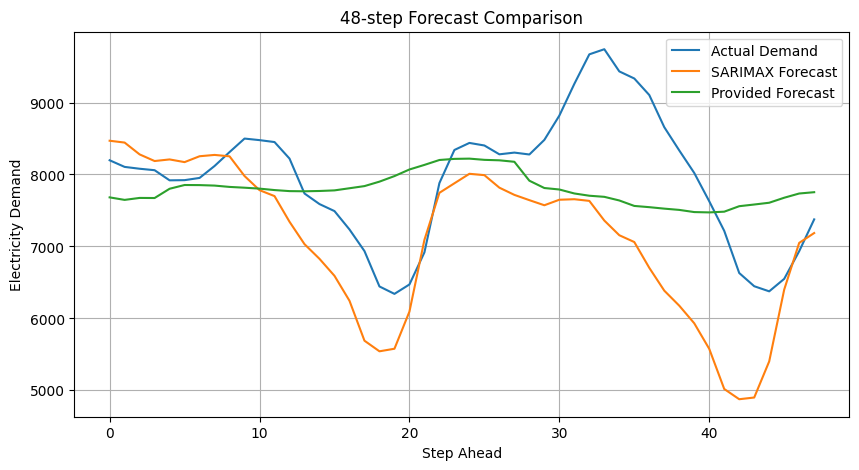

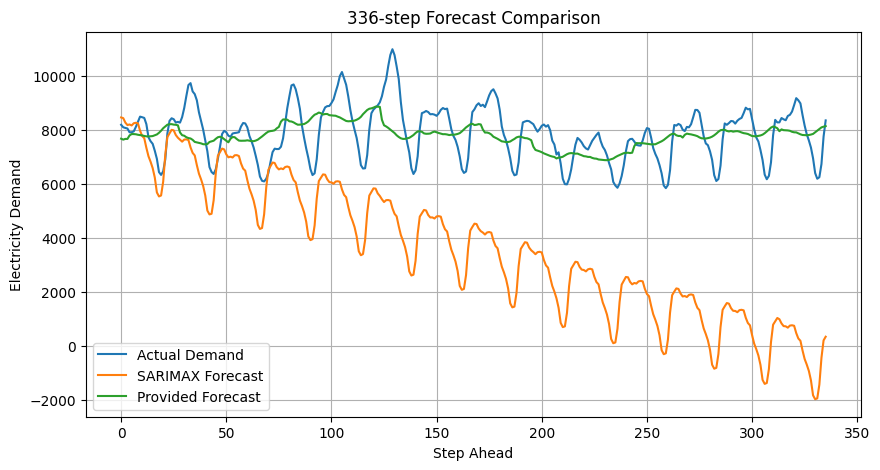

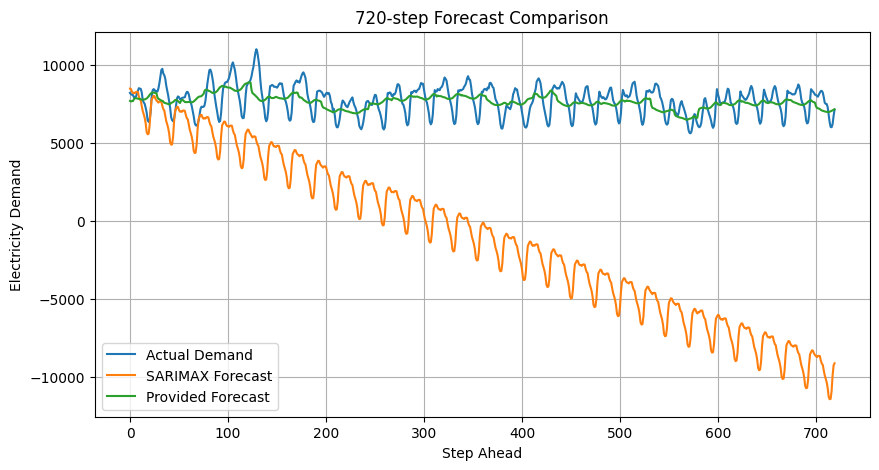

In [55]:
for h in horizons:
    y_actual, y_pred, rmse, mse = baseline_results[h]
    provided = X_test.iloc[window_start:window_start + h]['FORECASTDEMAND']

    plot_forecast(
        y_actual,
        y_pred,
        provided,
        h,
        'SARIMAX Forecast'
    )

The baseline SARIMAX model performs reasonably well for short-term forecasting, particularly at the 48-step horizon, where it captures the general trend and daily pattern of electricity demand. However, it consistently underestimates peak demand and struggles to fully capture the amplitude of fluctuations.

As the forecast horizon increases, model performance deteriorates significantly. At the 336-step and 720-step horizons, the forecasts exhibit a clear downward drift and become increasingly unrealistic, eventually producing negative demand values. This indicates that errors accumulate over time and the model is unable to maintain stable long-term predictions.

Overall, while the baseline model provides a useful starting point, its limitations in capturing peak demand and long-term behaviour highlight the need for model improvements.

## 7. Improved SARIMAX Model (with MA term)

### 7.1 Model Specification

To improve upon the baseline model, a moving average (MA) component is introduced. The inclusion of an MA term allows the model to account for past forecast errors, which can help stabilise predictions and improve short-term accuracy.

The updated model retains the same exogenous variables (temperature and provided forecast demand) and seasonal structure, ensuring that any changes in performance can be attributed specifically to the addition of the MA term.

The improved model specification is:
- non-seasonal order: (1,1,1)
- seasonal order: (0,1,0,24)

This model builds directly on the baseline and aims to reduce residual autocorrelation and improve forecasting performance.

In [56]:
# Fit improved SARIMAX model (with MA term)
model_ma = SARIMAX(
    y_train_clean,
    exog=X_train_clean,
    order=(1, 1, 1),  # only change from baseline
    seasonal_order=(0, 1, 0, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_ma = model_ma.fit(disp=False, maxiter=50)

### 7.2 Forecasting Results

The improved SARIMAX model is evaluated using the same forecast window and horizons as the baseline model to ensure a fair comparison.

Forecasts are generated for:
- 48 steps (2 days)
- 336 steps (2 weeks)
- 720 steps (30 days)

Performance is assessed using RMSE and MSE, and visual comparison is used to evaluate improvements in capturing demand patterns and peak behaviour.

In [57]:
ma_results = {}

for h in horizons:
    y_actual, y_pred, rmse, mse = run_forecast(
        results_ma, X_test[['TEMPERATURE', 'FORECASTDEMAND']], y_test, window_start, h
    )
    ma_results[h] = (y_actual, y_pred, rmse, mse)

    print(f"[MA Model] Horizon {h}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MSE: {mse:.2f}")
    print("-" * 30)

[MA Model] Horizon 48
RMSE: 1148.12
MSE: 1318172.01
------------------------------
[MA Model] Horizon 336
RMSE: 4405.40
MSE: 19407515.55
------------------------------
[MA Model] Horizon 720
RMSE: 9059.36
MSE: 82072003.66
------------------------------


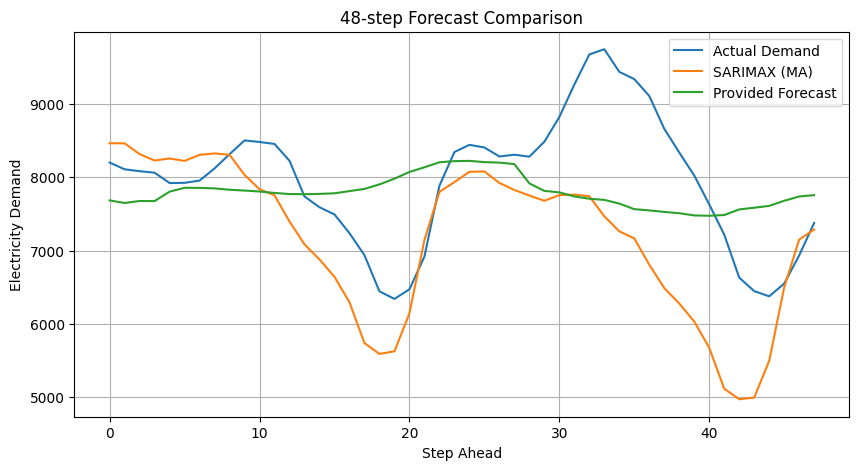

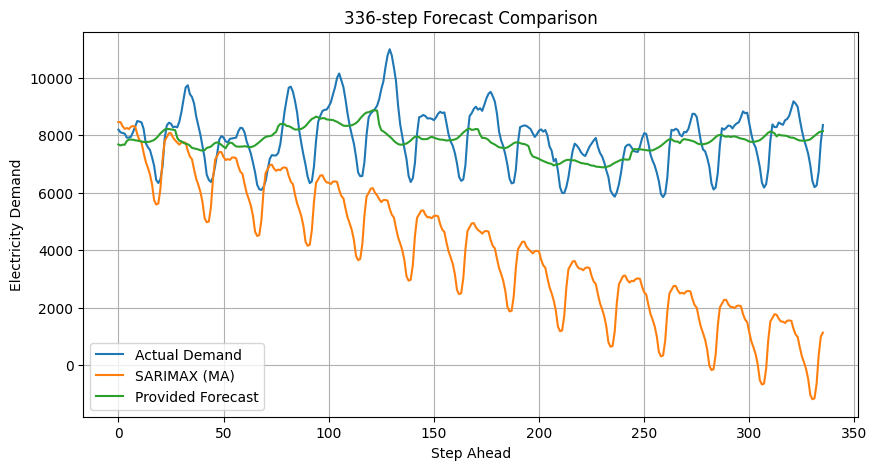

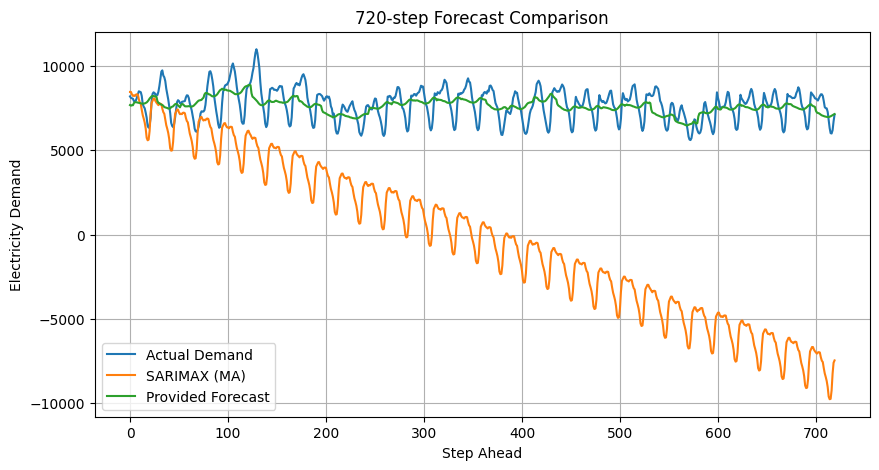

In [58]:
for h in horizons:
    y_actual, y_pred, rmse, mse = ma_results[h]
    provided = X_test.iloc[window_start:window_start + h]['FORECASTDEMAND']

    plot_forecast(
        y_actual,
        y_pred,
        provided,
        h,
        'SARIMAX (MA)'
    )

The inclusion of a moving average (MA) term results in a consistent improvement in forecasting performance across all horizons when compared to the baseline model.

For the 48-step horizon, the MA model produces a lower RMSE and more closely follows the observed demand pattern. This indicates improved short-term accuracy and a better ability to capture fluctuations in electricity demand.

At longer horizons (336 and 720 steps), the MA model continues to outperform the baseline in terms of error metrics. However, while the forecasts show slightly improved stability, the model still exhibits significant downward drift and fails to accurately capture peak demand.

Overall, the MA term improves model performance by accounting for past forecast errors, but it does not fully resolve the limitations of the SARIMAX model for long-term forecasting.

## 8. SARIMAX Model with Nonlinear Term (Temperature²)

### 8.1 Model Specification

Further improvements to the model were explored through feature engineering. Analysis of the data suggested that the relationship between temperature and electricity demand is nonlinear. Specifically, demand increases at both low temperatures (heating) and high temperatures (cooling), resulting in a U-shaped relationship.

To capture this behaviour, a quadratic temperature term was introduced by including the square of the temperature as an additional exogenous variable. This allows the SARIMAX model to better represent the nonlinear impact of temperature on electricity demand while maintaining a relatively simple model structure.

The updated set of exogenous variables is:
- temperature
- temperature squared
- provided forecast demand

All other aspects of the model remain unchanged from the previous model, including the MA term and seasonal structure. This ensures that any observed improvements in performance can be attributed to the inclusion of the nonlinear temperature feature.

The model specification is:
- non-seasonal order: (1,1,1)
- seasonal order: (0,1,0,24)

In [59]:
# Create nonlinear temperature feature
train['TEMP_SQUARED'] = train['TEMPERATURE'] ** 2
validation['TEMP_SQUARED'] = validation['TEMPERATURE'] ** 2
test['TEMP_SQUARED'] = test['TEMPERATURE'] ** 2

# Update exogenous variables
exog_vars = ['TEMPERATURE', 'TEMP_SQUARED', 'FORECASTDEMAND']

X_train = train[exog_vars]
X_test = test[exog_vars]

# Clean and align training data
combined_train = pd.concat([y_train, X_train], axis=1).dropna()

y_train_clean = combined_train['TOTALDEMAND']
X_train_clean = combined_train[exog_vars]

# Fit SARIMAX model with nonlinear feature
model_temp = SARIMAX(
    y_train_clean,
    exog=X_train_clean,
    order=(1, 1, 1),
    seasonal_order=(0, 1, 0, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_temp = model_temp.fit(disp=False, maxiter=50)

### 8.2 Forecasting Results

The model incorporating the quadratic temperature term is evaluated using the same forecast window and horizons as the previous models to ensure a fair comparison.

Forecasts are generated for:
- 48 steps (2 days)
- 336 steps (2 weeks)
- 720 steps (30 days)

Performance is assessed using RMSE and MSE, and visual comparison is used to evaluate improvements in capturing nonlinear demand behaviour and peak demand.

In [60]:
temp_results = {}

for h in horizons:
    y_actual, y_pred, rmse, mse = run_forecast(
        results_temp, X_test, y_test, window_start, h
    )
    temp_results[h] = (y_actual, y_pred, rmse, mse)

    print(f"[TEMP² Model] Horizon {h}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MSE: {mse:.2f}")
    print("-" * 30)

[TEMP² Model] Horizon 48
RMSE: 1138.06
MSE: 1295183.21
------------------------------
[TEMP² Model] Horizon 336
RMSE: 4370.75
MSE: 19103477.57
------------------------------
[TEMP² Model] Horizon 720
RMSE: 8991.92
MSE: 80854691.60
------------------------------


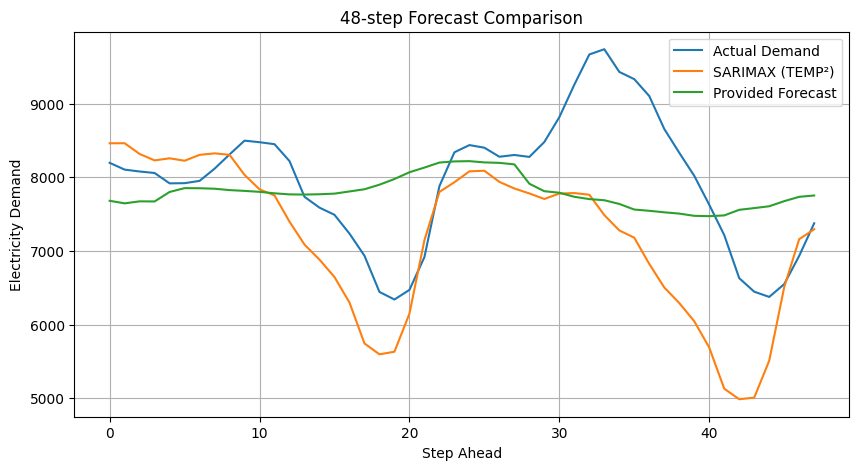

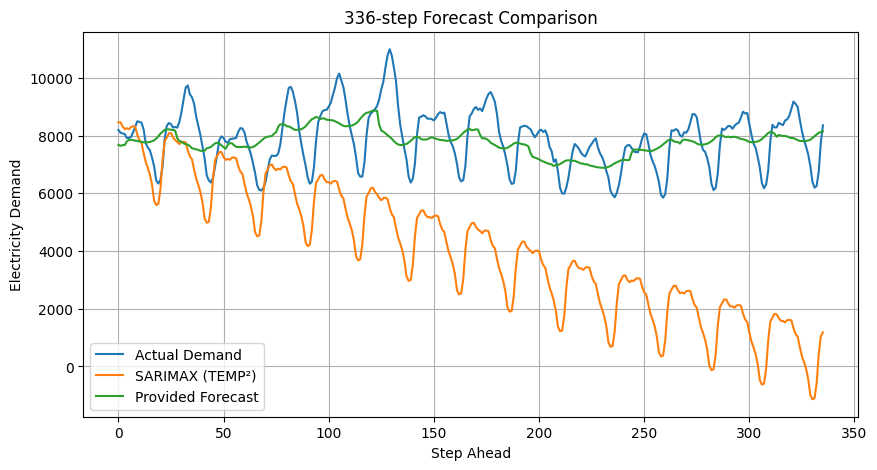

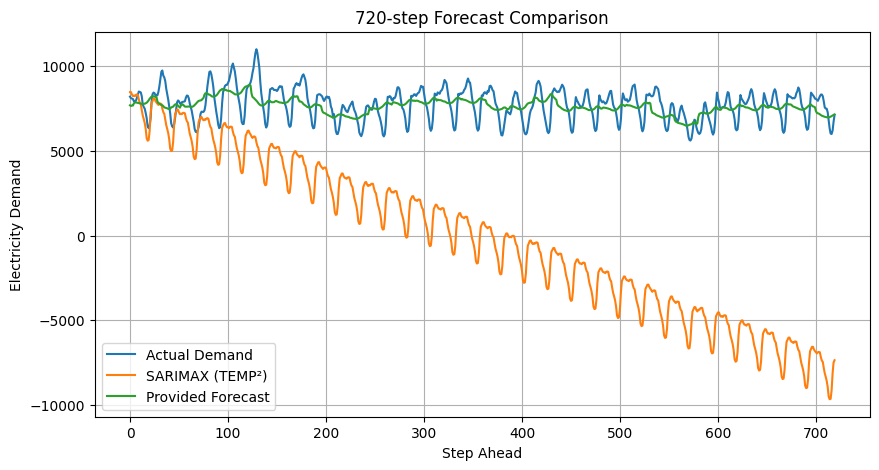

In [61]:
for h in horizons:
    y_actual, y_pred, rmse, mse = temp_results[h]
    provided = X_test.iloc[window_start:window_start + h]['FORECASTDEMAND']

    plot_forecast(
        y_actual,
        y_pred,
        provided,
        h,
        'SARIMAX (TEMP²)'
    )

The inclusion of a quadratic temperature term results in a further improvement in forecasting performance across all horizons when compared to the previous model.

For the 48-step horizon, the model demonstrates a slightly lower RMSE and improved alignment with the observed demand pattern. This indicates that capturing the nonlinear relationship between temperature and electricity demand enhances short-term forecasting accuracy.

At longer horizons (336 and 720 steps), the model continues to show marginal improvements in error metrics. However, similar to previous models, forecasting performance deteriorates over time, with predictions exhibiting downward drift and failing to accurately capture peak demand.

Overall, incorporating the nonlinear temperature feature provides a meaningful but limited improvement. While it better reflects real-world behaviour, it does not fully overcome the limitations of the SARIMAX framework for long-term forecasting.

## 9. Model Comparison and Discussion

The performance of the three SARIMAX models was evaluated across multiple forecast horizons to assess the impact of model improvements.

Across all models, the baseline SARIMAX model provided reasonable short-term forecasts but struggled to capture peak demand and exhibited significant degradation over longer horizons. The addition of a moving average (MA) term resulted in consistent improvements in RMSE across all forecast horizons, indicating that accounting for past forecast errors improves model stability and short-term accuracy.

Further improvements were observed when incorporating a quadratic temperature term. This allowed the model to better capture the nonlinear relationship between temperature and electricity demand, where both high and low temperatures lead to increased energy usage. As a result, the TEMP² model achieved the lowest RMSE values across all horizons.

Despite these improvements, all models exhibited similar limitations. Forecast accuracy deteriorated significantly as the prediction horizon increased, with all models showing a tendency toward downward drift and an inability to capture peak demand in the long term. This highlights a key limitation of SARIMAX models, where errors accumulate over time and the model struggles to maintain realistic long-term behaviour.

When compared to the provided forecast, the SARIMAX models generally perform better in capturing short-term fluctuations but are less stable over longer horizons. The provided forecast remains relatively smooth and stable, suggesting that it may incorporate additional information or modelling techniques not captured by the SARIMAX approach.

Overall, the results demonstrate that while incremental improvements can enhance SARIMAX performance, the model is inherently limited in handling complex and long-term forecasting tasks. This motivates the use of more advanced models, such as deep learning approaches, which are better suited to capturing nonlinear patterns and long-range dependencies.

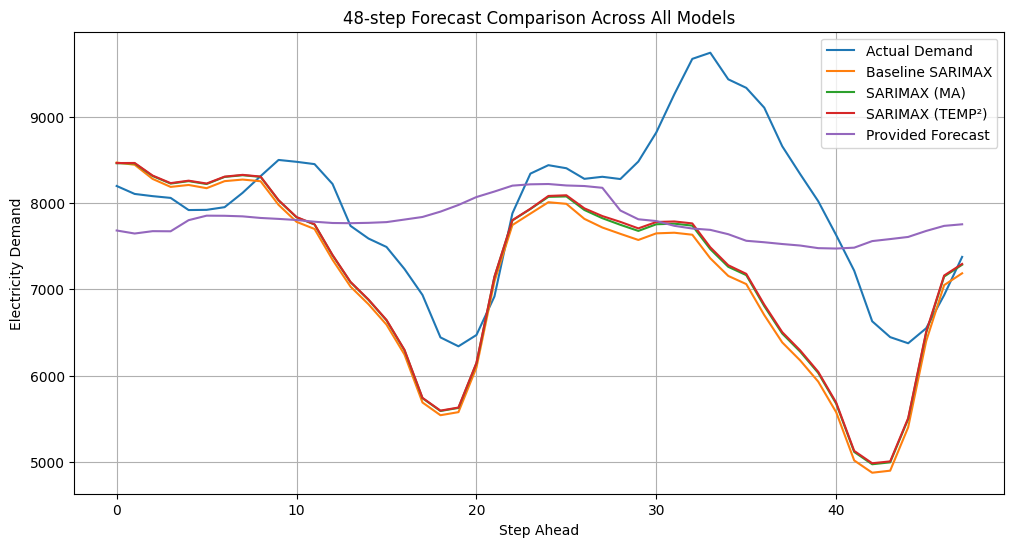

In [62]:
# Extract 48-step results
y_actual_48 = baseline_results[48][0]
y_pred_baseline_48 = baseline_results[48][1]
y_pred_ma_48 = ma_results[48][1]
y_pred_temp_48 = temp_results[48][1]
provided_48 = X_test.iloc[window_start:window_start + 48]['FORECASTDEMAND']

plt.figure(figsize=(12, 6))

plt.plot(range(48), y_actual_48.values, label='Actual Demand')
plt.plot(range(48), y_pred_baseline_48.values, label='Baseline SARIMAX')
plt.plot(range(48), y_pred_ma_48.values, label='SARIMAX (MA)')
plt.plot(range(48), y_pred_temp_48.values, label='SARIMAX (TEMP²)')
plt.plot(range(48), provided_48.values, label='Provided Forecast')

plt.title('48-step Forecast Comparison Across All Models')
plt.xlabel('Step Ahead')
plt.ylabel('Electricity Demand')
plt.legend()
plt.grid()
plt.show()

In [63]:
# -------------------------------
# Create RMSE and MSE tables (clean formatting)
# -------------------------------

import pandas as pd

# Helper to format numbers nicely
def format_number(x):
    return f"{int(round(x)):,}"

# Build RMSE table
rmse_table = pd.DataFrame({
    "Model": ["Baseline", "MA", "TEMP²"],
    "48-step": [
        baseline_results[48][2],
        ma_results[48][2],
        temp_results[48][2]
    ],
    "336-step": [
        baseline_results[336][2],
        ma_results[336][2],
        temp_results[336][2]
    ],
    "720-step": [
        baseline_results[720][2],
        ma_results[720][2],
        temp_results[720][2]
    ]
})

# Build MSE table
mse_table = pd.DataFrame({
    "Model": ["Baseline", "MA", "TEMP²"],
    "48-step": [
        baseline_results[48][3],
        ma_results[48][3],
        temp_results[48][3]
    ],
    "336-step": [
        baseline_results[336][3],
        ma_results[336][3],
        temp_results[336][3]
    ],
    "720-step": [
        baseline_results[720][3],
        ma_results[720][3],
        temp_results[720][3]
    ]
})

# Find best rows
rmse_best = {col: rmse_table[col].idxmin() for col in ["48-step", "336-step", "720-step"]}
mse_best = {col: mse_table[col].idxmin() for col in ["48-step", "336-step", "720-step"]}

# Format tables
rmse_display = rmse_table.copy()
mse_display = mse_table.copy()

for col in ["48-step", "336-step", "720-step"]:
    rmse_display[col] = rmse_display[col].apply(format_number)
    mse_display[col] = mse_display[col].apply(format_number)

# Display RMSE
print("RMSE Comparison")
display(rmse_display)

print("Best RMSE values:")
for col in rmse_best:
    idx = rmse_best[col]
    val = format_number(rmse_table.loc[idx, col])
    model = rmse_table.loc[idx, "Model"]
    print(f"{col}: {model} ({val})")

# Display MSE
print("\nMSE Comparison")
display(mse_display)

print("Best MSE values:")
for col in mse_best:
    idx = mse_best[col]
    val = format_number(mse_table.loc[idx, col])
    model = mse_table.loc[idx, "Model"]
    print(f"{col}: {model} ({val})")

RMSE Comparison


,Model,48-step,336-step,720-step
0,Baseline,"1,212","4,870","10,044"
1,MA,"1,148","4,405","9,059"
2,TEMP²,"1,138","4,371","8,992"


Best RMSE values:
48-step: TEMP² (1,138)
336-step: TEMP² (4,371)
720-step: TEMP² (8,992)

MSE Comparison


,Model,48-step,336-step,720-step
0,Baseline,"1,469,490","23,715,935","100,887,151"
1,MA,"1,318,172","19,407,516","82,072,004"
2,TEMP²,"1,295,183","19,103,478","80,854,692"


Best MSE values:
48-step: TEMP² (1,295,183)
336-step: TEMP² (19,103,478)
720-step: TEMP² (80,854,692)


## 10. Conclusion

This notebook developed and evaluated a series of SARIMAX models for forecasting NSW electricity demand across multiple time horizons.

The baseline model provided a reasonable starting point, capturing short-term patterns but failing to accurately model peak demand and long-term behaviour. The introduction of a moving average (MA) term resulted in consistent improvements in forecasting accuracy, particularly for shorter horizons. Further gains were achieved by incorporating a nonlinear temperature feature, which better captured the U-shaped relationship between temperature and electricity demand.

Despite these improvements, all models exhibited similar limitations. Forecast accuracy deteriorated significantly as the prediction horizon increased, with forecasts becoming unstable and failing to capture realistic long-term demand patterns. This highlights the inherent limitations of SARIMAX models in handling complex, nonlinear, and long-range dependencies.

Overall, while SARIMAX provides a useful and interpretable statistical baseline, more advanced modelling approaches are required for accurate long-term electricity demand forecasting. These findings motivate the comparison with more sophisticated models in the final report.